In [1]:
import zipfile

with zipfile.ZipFile("final_processed_data.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [1]:
import torch
import torch.nn as nn
import torch.autograd as autograd
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils
import matplotlib.pyplot as plt
from pathlib import Path
import os
import torch
from torch import nn, autograd
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets
from PIL import Image
import numpy as np


#  WGAN tuning structure

In [2]:

# --- Config ---
img_size = 64
batch_size = 32  
z_dim = 128      
lr = 5e-5        
epochs = 10      
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Transforms & Dataset (limited to 10000 samples) ---
tf = transforms.Compose([
    transforms.Resize(img_size),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,) * 3, (0.5,) * 3),
])

TRAIN_DIR = "data/final_processed_data/train"  # UPDATE THIS
full_ds = datasets.ImageFolder(root=TRAIN_DIR, transform=tf)
subset_ds = Subset(full_ds, range(min(10000, len(full_ds)))) 
train_dl = DataLoader(subset_ds, batch_size=batch_size, shuffle=True, num_workers=2)

# --- Generator & Critic ---
class Generator(nn.Module):
    def __init__(self, z_dim=128, img_channels=3, feature_g=64):  # TUNE feature_g
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, feature_g * 8 * 4 * 4),
            nn.ReLU(True),
            nn.Unflatten(1, (feature_g * 8, 4, 4)),
            nn.ConvTranspose2d(feature_g * 8, feature_g * 4, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 4, feature_g * 2, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(feature_g * 2, feature_g, 4, 2, 1), nn.ReLU(True),
            nn.ConvTranspose2d(feature_g, img_channels, 4, 2, 1), nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, img_channels=3, feature_d=64):  # TUNE feature_d
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, feature_d, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d, feature_d * 2, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 2, feature_d * 4, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_d * 4, feature_d * 8, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(feature_d * 8 * 4 * 4, 1),
        )

    def forward(self, x):
        return self.net(x)

# --- Gradient Penalty ---
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    critic_interpolated = critic(interpolated)
    gradients = autograd.grad(
        outputs=critic_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_interpolated),
        create_graph=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

# --- Tuning Training Function ---
def train_tuning(G, C, dl, z_dim, lr, device, critic_iters=5, lambda_gp=10, n_epochs=10):
    G, C = G.to(device), C.to(device)
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    optC = torch.optim.Adam(C.parameters(), lr=lr, betas=(0.0, 0.9))

    for epoch in range(1, n_epochs + 1):
        for i, (real_imgs, _) in enumerate(dl):
            real_imgs = real_imgs.to(device)
            bsz = real_imgs.size(0)

            for _ in range(critic_iters):
                z = torch.randn(bsz, z_dim, device=device)
                fake_imgs = G(z).detach()
                real_score = C(real_imgs)
                fake_score = C(fake_imgs)
                gp = gradient_penalty(C, real_imgs, fake_imgs, device)
                c_loss = fake_score.mean() - real_score.mean() + lambda_gp * gp

                optC.zero_grad()
                c_loss.backward()
                optC.step()

            # Generator
            z = torch.randn(bsz, z_dim, device=device)
            gen_imgs = G(z)
            g_loss = -C(gen_imgs).mean()

            optG.zero_grad()
            g_loss.backward()
            optG.step()

        print(f"[Epoch {epoch}] C_loss: {c_loss.item():.4f}, G_loss: {g_loss.item():.4f}")

    return G, C

# --- RUN ---
G = Generator(z_dim=z_dim)
C = Critic()
G, C = train_tuning(G, C, train_dl, z_dim=z_dim, lr=lr, device=device, n_epochs=epochs)


[Epoch 1] C_loss: -144.1554, G_loss: 39.0160
[Epoch 2] C_loss: -118.9166, G_loss: 15.7693
[Epoch 3] C_loss: -158.7252, G_loss: 29.4904
[Epoch 4] C_loss: -104.6766, G_loss: 11.6139
[Epoch 5] C_loss: -96.3218, G_loss: -13.0883
[Epoch 6] C_loss: -82.4993, G_loss: -31.9914
[Epoch 7] C_loss: -66.0771, G_loss: -44.4119
[Epoch 8] C_loss: -80.9652, G_loss: -49.9816
[Epoch 9] C_loss: -82.9389, G_loss: -37.5556
[Epoch 10] C_loss: -68.1799, G_loss: -34.1864


#  Checking accuracy parameter

In [3]:
import torch
import numpy as np
from PIL import Image
from torchvision.transforms.functional import resize
from torch.nn.functional import interpolate
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance
import os

# Ensure G is in eval mode
G.eval()

# --- Generate and Save 5 Samples ---
for i in range(5):
    with torch.no_grad():
        z = torch.randn(1, z_dim, device=device)
        sample = G(z)
        img = sample[0].cpu().numpy()
        img = np.transpose(img, (1, 2, 0))  # CHW -> HWC
        img = (img * 0.5) + 0.5  # Denormalize
        img = np.clip(img, 0, 1)
        img_uint8 = (img * 255).astype(np.uint8)
        Image.fromarray(img_uint8).save(f"sample_{i+1}.png")
        print(f"Saved: sample_{i+1}.png")

# --- Create 100 Fake Images for Metric Evaluation ---
fake_imgs = []
for _ in range(100):
    z = torch.randn(1, z_dim, device=device)
    with torch.no_grad():
        img = G(z).cpu()
    img = interpolate(img, size=(299, 299), mode='bilinear', align_corners=False)
    fake_imgs.append(img)
fake_imgs = torch.cat(fake_imgs, dim=0)

# --- Load 5 Real Images from Validation Set ---
REAL_VAL_PATH = "data/final_processed_data/val/food"  # e.g., '.../val/food'
real_imgs = []
real_files = [os.path.join(REAL_VAL_PATH, fname) for fname in os.listdir(REAL_VAL_PATH) if fname.lower().endswith(('.jpg', '.png'))][:5]

for fname in real_files:
    img = Image.open(fname).convert('RGB').resize((299, 299))
    img = np.asarray(img).astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # HWC -> CHW
    real_imgs.append(img)
real_imgs = torch.cat(real_imgs, dim=0)

# --- Inception Score ---
is_metric = InceptionScore(normalize=True)
is_score, is_std = is_metric(fake_imgs)
print(f"Inception Score: {is_score:.4f} ± {is_std:.4f}")

# --- FID Score ---
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True)
fid_metric.update(real_imgs, real=True)
fid_metric.update(fake_imgs, real=False)
fid_value = fid_metric.compute()
print(f"FID: {fid_value:.4f}")


Saved: sample_1.png
Saved: sample_2.png
Saved: sample_3.png
Saved: sample_4.png
Saved: sample_5.png


C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Inception Score: 1.6294 ± 0.1198
FID: 424.1415


In [4]:
import itertools

# Define grid of parameters to test
param_grid = {
    "z_dim": [64, 128],
    "lr": [1e-4, 5e-5],
    "batch_size": [32, 64],
    "feature_g": [32, 64],
    "feature_d": [32, 64]
}

# Cartesian product of parameter combinations
param_combinations = list(itertools.product(*param_grid.values()))
param_keys = list(param_grid.keys())


In [5]:
def run_experiment(params, exp_id):
    config = dict(zip(param_keys, params))
    print(f"\n=== Running Experiment {exp_id} with config: {config} ===")

    # Update globals (optional: you can refactor to pass inside train_tuning if needed)
    z_dim = config['z_dim']
    lr = config['lr']
    batch_size = config['batch_size']
    feature_g = config['feature_g']
    feature_d = config['feature_d']

    # Redefine dataloader
    train_dl = DataLoader(subset_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    # Initialize models
    G = Generator(z_dim=z_dim, feature_g=feature_g).to(device)
    C = Critic(feature_d=feature_d).to(device)

    # Train
    G, C = train_tuning(G, C, train_dl, z_dim=z_dim, lr=lr, device=device, n_epochs=epochs)

    # Save 5 generated images
    os.makedirs(f"outputs2/exp_{exp_id}", exist_ok=True)
    G.eval()
    for i in range(5):
        with torch.no_grad():
            z = torch.randn(1, z_dim, device=device)
            sample = G(z)
            img = sample[0].cpu().numpy()
            img = np.transpose(img, (1, 2, 0))
            img = (img * 0.5) + 0.5
            img = np.clip(img, 0, 1)
            img_uint8 = (img * 255).astype(np.uint8)
            Image.fromarray(img_uint8).save(f"outputs2/exp_{exp_id}/sample_{i+1}.png")

    # Metrics
    fake_imgs = []
    for _ in range(100):
        z = torch.randn(1, z_dim, device=device)
        with torch.no_grad():
            img = G(z).cpu()
        img = interpolate(img, size=(299, 299), mode='bilinear', align_corners=False)
        fake_imgs.append(img)
    fake_imgs = torch.cat(fake_imgs, dim=0)

    real_imgs = []
    for fname in real_files:
        img = Image.open(fname).convert('RGB').resize((299, 299))
        img = np.asarray(img).astype(np.float32) / 255.0
        img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)
        real_imgs.append(img)
    real_imgs = torch.cat(real_imgs, dim=0)

    is_metric = InceptionScore(normalize=True)
    is_score, is_std = is_metric(fake_imgs)

    fid_metric = FrechetInceptionDistance(feature=2048, normalize=True)
    fid_metric.update(real_imgs, real=True)
    fid_metric.update(fake_imgs, real=False)
    fid_value = fid_metric.compute()
                                            
    # Save metrics
    with open(f"outputs/exp_{exp_id}/metrics.txt", "w") as f:
        f.write(f"Config: {config}\n")
        f.write(f"Inception Score: {is_score:.4f} ± {is_std:.4f}\n")
        f.write(f"FID: {fid_value:.4f}\n")

    print(f"Exp {exp_id} done | IS: {is_score:.2f} ± {is_std:.2f} | FID: {fid_value:.2f}")


In [7]:
for idx, params in enumerate(param_combinations[:2]):
    run_experiment(params, exp_id=idx+1)



=== Running Experiment 1 with config: {'z_dim': 64, 'lr': 0.0001, 'batch_size': 32, 'feature_g': 32, 'feature_d': 32} ===
[Epoch 1] C_loss: -129.3218, G_loss: 20.1407
[Epoch 2] C_loss: -134.7563, G_loss: -10.3093
[Epoch 3] C_loss: -87.4673, G_loss: 5.6203
[Epoch 4] C_loss: -65.2029, G_loss: -4.1344
[Epoch 5] C_loss: -96.0174, G_loss: -1.7465
[Epoch 6] C_loss: -57.0897, G_loss: -74.6628
[Epoch 7] C_loss: -47.7228, G_loss: -50.6088
[Epoch 8] C_loss: -50.9227, G_loss: -75.1625
[Epoch 9] C_loss: -47.5606, G_loss: -78.6156
[Epoch 10] C_loss: -42.1797, G_loss: -41.8466
Exp 1 done | IS: 1.69 ± 0.20 | FID: 438.37

=== Running Experiment 2 with config: {'z_dim': 64, 'lr': 0.0001, 'batch_size': 32, 'feature_g': 32, 'feature_d': 64} ===
[Epoch 1] C_loss: -144.8918, G_loss: -1.2981
[Epoch 2] C_loss: -115.7445, G_loss: -55.3850
[Epoch 3] C_loss: -107.5221, G_loss: -68.1931
[Epoch 4] C_loss: -78.1819, G_loss: -98.5202
[Epoch 5] C_loss: -70.5008, G_loss: -84.2402
[Epoch 6] C_loss: -75.8206, G_loss: 

#  Vanishing Gradient checking

In [9]:
epoch = 5
grad_norm = 0.0
for p in G.parameters():
    if p.grad is not None:
        grad_norm += p.grad.data.norm(2).item()
print(f"[Epoch {epoch}] Grad Norm: {grad_norm:.4f}")


[Epoch 5] Grad Norm: 943.1934


#  Mode collapse checking

In [13]:
import matplotlib.pyplot as plt

def check_mode_collapse(G, z_dim, device, exp_id):
    G.eval()
    n_samples = 8
    z = torch.randn(n_samples, z_dim, device=device)
    with torch.no_grad():
        samples = G(z).cpu()
    samples = (samples * 0.5) + 0.5  # Denormalize

    fig, axs = plt.subplots(1, n_samples, figsize=(15, 3))
    for i in range(n_samples):
        img = samples[i].permute(1, 2, 0).numpy()
        axs[i].imshow(np.clip(img, 0, 1))
        axs[i].axis("off")
    plt.suptitle(f"Exp {exp_id} - Visual Check for Mode Collapse")
    plt.show()


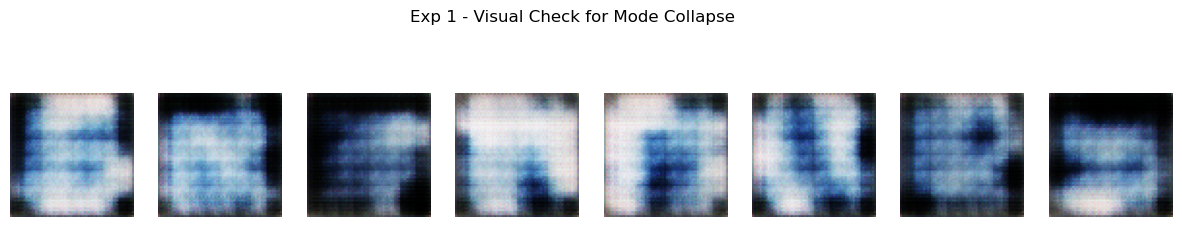

In [16]:
check_mode_collapse(G, z_dim,device='cpu', exp_id=1)

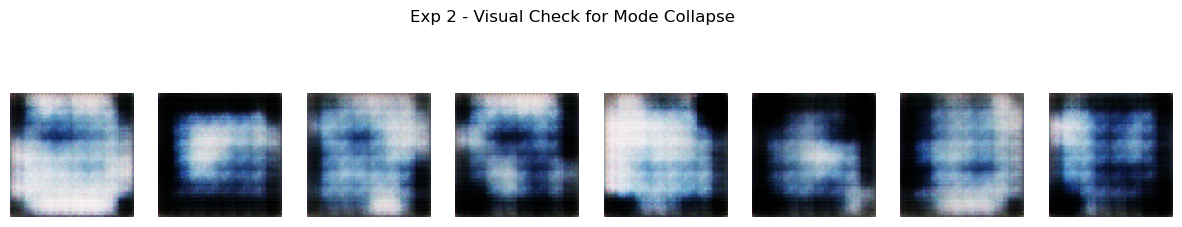

In [17]:
check_mode_collapse(G, z_dim,device='cpu', exp_id=2)

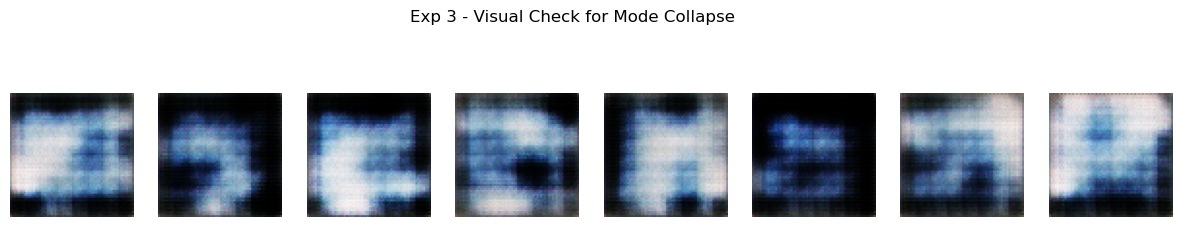

In [18]:
check_mode_collapse(G, z_dim,device='cpu', exp_id=3)

#  Insights from above results

Despite two rounds of hyperparameter tuning, the WGAN model struggled to generate high-quality images. The Inception Scores remained low (~1.7–1.8), and the FID scores were very high (438–443), indicating that the generated images were far from realistic and lacked diversity.

#  Next steps to be done for better results 

1. Increasing the epochs

2. Using larger Generator and critic

3. Improve the input noise
